# Part 1: Setting Up Our System 🏗️

Welcome to the first notebook of our workshop\! In this section, we'll learn how to take a chemical from a simple name or text string and turn it into a full 3D model ready for simulation. We'll finish by creating a "simulation box" filled with water molecules, which will be our thermodynamic **system**.

First, let's install and import the necessary Python libraries.

In [1]:
! pip install rdkit py3Dmol ase nglview

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.9/21.9 MB 51.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.2/388.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Import libraries
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import py3Dmol
from ase import Atoms
from ase.build import bulk
from ase.visualize import view
import nglview as nv

-----

## 1.1 Computer Representations of Molecules

Computers don't understand chemical names like "ethanol," but they can understand standardized text representations. One of the most common is **SMILES** (Simplified Molecular-Input Line-Entry System). It's a simple way to write down a chemical structure in a single line of text.


In [3]:
# Define SMILES strings for our molecules
smiles_water = 'O'
smiles_methanol = 'CO'

# Create RDKit molecule objects from the SMILES strings
mol_water = Chem.MolFromSmiles(smiles_water)
mol_methanol = Chem.MolFromSmiles(smiles_methanol)

# Add hydrogen atoms to the molecules (RDKit often assumes them)
mol_water = Chem.AddHs(mol_water)
mol_methanol = Chem.AddHs(mol_methanol)

# Generate a 3D conformation for the molecules
AllChem.EmbedMolecule(mol_water)
AllChem.EmbedMolecule(mol_methanol)

0

### Visualizing 2D Structures (ChemDraw Style)

Before we create a 3D model, it's good practice to generate a 2D image to make sure our SMILES string was interpreted correctly. The `rdkit` library can do this for us easily.

2D Structure of Water:


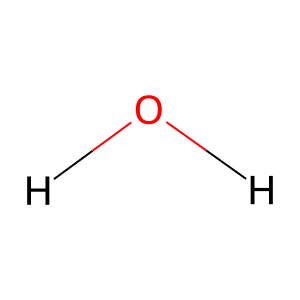


2D Structure of Methanol:


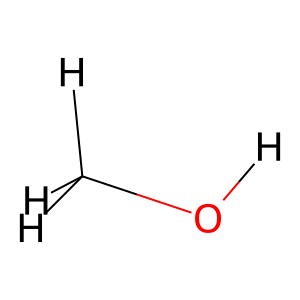

In [4]:
# Generate and display 2D images for water and ethanol
img_water = Draw.MolToImage(mol_water)
img_methanol = Draw.MolToImage(mol_methanol)

print("2D Structure of Water:")
display(img_water)

print("\n2D Structure of Methanol:")
display(img_methanol)

### Generating and Visualizing 3D Structures

Now that we've confirmed our 2D structures are correct, we can proceed to generate a 3D conformation for the molecules.

In [5]:
# Generate a 3D conformation for the molecules
AllChem.EmbedMolecule(mol_water)
AllChem.EmbedMolecule(mol_methanol)

# --- Visualize the methanol molecule ---

# Convert the RDKit molecule to a string format that py3Dmol can read
mol_block = Chem.MolToMolBlock(mol_methanol)

# Set up the viewer
viewer = py3Dmol.view(width=400, height=300)

# Add the molecule data to the viewer
viewer.addModel(mol_block, 'mol')

# Style the molecule as sticks
viewer.setStyle({'stick': {}})

# Zoom to fit the molecule
viewer.zoomTo()

# Show the viewer
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

-----

### **📋 Reporting Task 1**

- What is the SMILES string for ethanol?
- Generate a 2D image of ethanol
- Generate a 3D structure of ethanol and view.

In [ ]:
# Define SMILES strings for ethanol

# Create RDKit molecule objects from the SMILES strings (do you need to add hydrogen atoms?)

# Generate a 2D image

# Generate a 3D conformation

# Visualise


-----

## 1.2 Building a Simulation Box

To study the properties of liquid argon, we need to simulate many molecules together. We'll create a cubic box and fill it with Argon molecules. To avoid strange "edge effects," our simulation will use **periodic boundary conditions**, meaning if a molecule leaves the box on one side, it re-enters from the opposite side—like in video games\!

We'll use the **Atomic Simulation Environment (ASE)** to build this system. We will create a 2x2x2 unit cell of a face centered cubic lattice and place one argon molecule at each lattice point.

In [12]:
# Load a simulation box we created in the previous notebook
argon_bulk = bulk('Ar', 'fcc', a=5.0, cubic=True)
simulation_box = argon_bulk.repeat((2, 2, 2))
print(f"Created a simulation box with {len(simulation_box)} Argon atoms.")

# Let's visualize our new simulation box
from ase.visualize import view
view(simulation_box, viewer='x3d')

Created a simulation box with 32 Argon atoms.


Our system is now set up\! This box of argon molecules is similar to the system we will use in the next notebook to run a full molecular dynamics simulation.

-----

### **📋 Reporting Task 2**

- Print the cell dimensions of your simulation box. The command is `simulation_box.cell`.

- Print the cell volume of your simulation box (units of ASE are Å).

- Compute the density of argon in this simulation box (give your answer in units kg/m3) How can we simply set the density to liquid Ar?

HINT: The code to return the total mass of the system (in units amu) is `total_mass_amu = np.sum(simulation_box.get_masses())`.

In [ ]:
# Answer goes here

-----

## Next Steps

Great job\! You've successfully created a simulation-ready system from scratch.

➡️ Now, proceed to the next notebook, **`02-RunMD.ipynb`**, to run a simulation.